Label counts:
 label
cry        565
not_cry    324
Name: count, dtype: int64
Split: train=641 val=114 test=134


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Model: tf_efficientnet_b0

--- Training ---
Epoch 01 | train loss 1.9587 acc 0.4914 | val loss 1.0959 acc 0.6667
Epoch 02 | train loss 0.7599 acc 0.7676 | val loss 0.8284 acc 0.7368
Epoch 03 | train loss 0.4197 acc 0.8721 | val loss 0.3212 acc 0.9035
Epoch 04 | train loss 0.3932 acc 0.8924 | val loss 0.2091 acc 0.9386
Epoch 05 | train loss 0.3119 acc 0.9220 | val loss 0.2440 acc 0.9298
Epoch 06 | train loss 0.2616 acc 0.9282 | val loss 0.2242 acc 0.9386
Epoch 07 | train loss 0.2351 acc 0.9329 | val loss 0.1996 acc 0.9474
Epoch 08 | train loss 0.1418 acc 0.9610 | val loss 0.2464 acc 0.9298
Epoch 09 | train loss 0.1734 acc 0.9485 | val loss 0.1739 acc 0.9386
Epoch 10 | train loss 0.2528 acc 0.9392 | val loss 0.3532 acc 0.9035
Epoch 11 | train loss 0.1535 acc 0.9516 | val loss 0.1921 acc 0.9474
Epoch 12 | train loss 0.1901 acc 0.9423 | val loss 0.2033 acc 0.9561
Epoch 13 | train loss 0.1031 acc 0.9657 | val loss 0.1551 acc 0.9737
Epoch 14 | train loss 0.0979 acc 0.9657 | val loss 0.1386 a

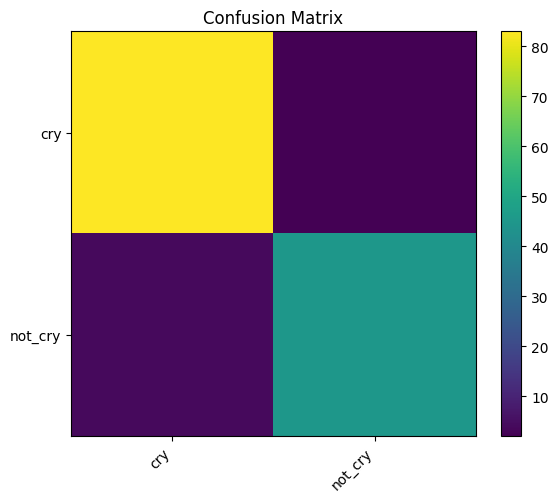

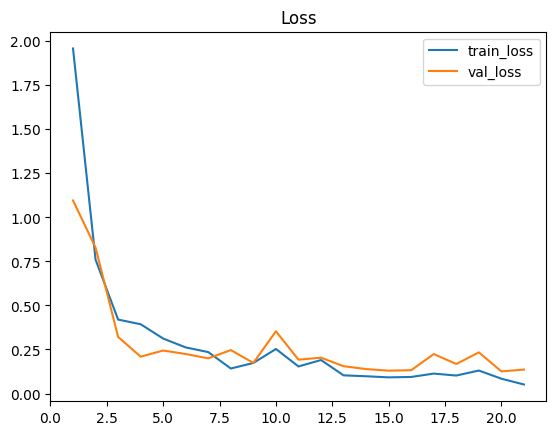

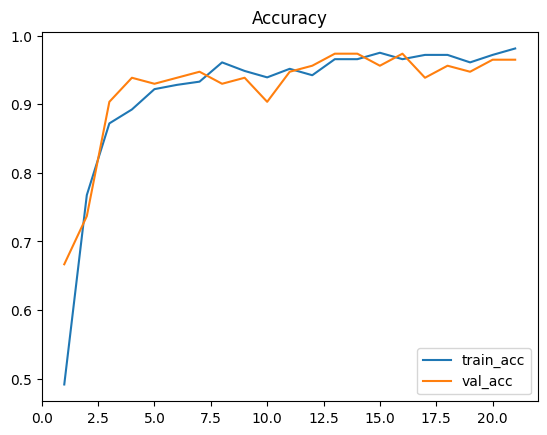


 Saved: best_model.pt
 Label map: {'cry': 0, 'not_cry': 1}


In [1]:
import os, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchaudio
import torchaudio.transforms as T

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# -------------------------
# Config
# -------------------------
SEED = 42
def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATASET_ROOT = Path("/kaggle/input/datasets/sanmithasadhish/infant-cry-dataset/Dataset")
CLASS_ROOT = DATASET_ROOT  # contains cry/ and not_cry/
AUDIO_EXTS = {".wav", ".flac", ".ogg", ".mp3", ".m4a", ".aac"}

TARGET_SR = 16000
SEG_SECONDS = 3.0
N_MELS = 128
N_FFT = 1024
HOP = 320
WIN = 1024
FMIN, FMAX = 50, 7600

BATCH = 32
EPOCHS = 40
LR = 3e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 8
NUM_WORKERS = 2  
PIN_MEMORY = True

AUG_WAVE_P = 0.7
AUG_SPEC_P = 0.8

# -------------------------
# Build df
# -------------------------
rows = []
for cls_dir in sorted([p for p in CLASS_ROOT.iterdir() if p.is_dir()]):
    for f in cls_dir.rglob("*"):
        if f.is_file() and f.suffix.lower() in AUDIO_EXTS:
            rows.append({"path": str(f), "label": cls_dir.name})
df = pd.DataFrame(rows)
print("Label counts:\n", df["label"].value_counts())

labels = sorted(df["label"].unique().tolist())
label_to_id = {l:i for i,l in enumerate(labels)}
df["y"] = df["label"].map(label_to_id)

train_df, test_df = train_test_split(df, test_size=0.15, random_state=SEED, stratify=df["y"])
train_df, val_df  = train_test_split(train_df, test_size=0.15, random_state=SEED, stratify=train_df["y"])
print(f"Split: train={len(train_df)} val={len(val_df)} test={len(test_df)}")

# -------------------------
# CPU preprocessing helpers
# -------------------------
def load_audio_cpu(path: str):
    wav, sr = torchaudio.load(path)  # CPU
    if wav.size(0) > 1:
        wav = wav.mean(dim=0, keepdim=True)
    wav = wav.squeeze(0)
    if sr != TARGET_SR:
        wav = torchaudio.functional.resample(wav, sr, TARGET_SR)
        sr = TARGET_SR
    return wav, sr

def pad_or_trim(wav: torch.Tensor, sr: int, seconds: float):
    n = int(sr * seconds)
    if wav.numel() < n:
        wav = F.pad(wav, (0, n - wav.numel()))
    else:
        wav = wav[:n]
    return wav

def trim_silence(wav: torch.Tensor, thr: float = 0.02):
    absw = wav.abs()
    m = absw.max().clamp(min=1e-8)
    mask = absw > (thr * m)
    if mask.any():
        idx = mask.nonzero(as_tuple=False).squeeze(1)
        wav = wav[idx[0]:idx[-1] + 1]
    return wav

def wave_aug(wav: torch.Tensor):
    if random.random() < AUG_WAVE_P:
        gain = 10 ** (random.uniform(-6, 6) / 20.0)
        wav = wav * gain
        if random.random() < 0.7:
            snr_db = random.uniform(10, 30)
            sigp = wav.pow(2).mean().clamp(min=1e-12)
            snr = 10 ** (snr_db / 10.0)
            noisep = sigp / snr
            wav = wav + torch.randn_like(wav) * noisep.sqrt()
        if random.random() < 0.5:
            shift = int(random.uniform(-0.08, 0.08) * TARGET_SR)
            wav = torch.roll(wav, shifts=shift)
    wav = wav / (wav.abs().max().clamp(min=1e-8))
    return wav

mel = T.MelSpectrogram(
    sample_rate=TARGET_SR,
    n_fft=N_FFT,
    win_length=WIN,
    hop_length=HOP,
    f_min=FMIN,
    f_max=FMAX,
    n_mels=N_MELS,
    power=2.0
)
amp_to_db = T.AmplitudeToDB(stype="power")
time_mask = T.TimeMasking(time_mask_param=48)
freq_mask = T.FrequencyMasking(freq_mask_param=20)

def make_logmel_cpu(wav: torch.Tensor):
    S = mel(wav)         # (mels, frames) CPU
    S = amp_to_db(S)     # dB
    S = (S - S.mean()) / (S.std().clamp(min=1e-6))
    return S

def spec_aug_cpu(S: torch.Tensor):
    if random.random() < AUG_SPEC_P:
        x = S.unsqueeze(0)
        x = time_mask(x)
        x = freq_mask(x)
        return x.squeeze(0)
    return S

class CryDS(Dataset):
    def __init__(self, frame: pd.DataFrame, train: bool):
        self.frame = frame.reset_index(drop=True)
        self.train = train

    def __len__(self): return len(self.frame)

    def __getitem__(self, idx):
        path = self.frame.loc[idx, "path"]
        y = int(self.frame.loc[idx, "y"])

        wav, sr = load_audio_cpu(path)
        wav = wav - wav.mean()
        wav = trim_silence(wav, thr=0.02)
        wav = pad_or_trim(wav, sr, SEG_SECONDS)
        wav = wav / (wav.abs().max().clamp(min=1e-8))

        if self.train:
            wav = wave_aug(wav)

        S = make_logmel_cpu(wav)
        if self.train:
            S = spec_aug_cpu(S)

        x = S.unsqueeze(0).repeat(3, 1, 1)  # (3, mels, frames) CPU
        return x.float(), torch.tensor(y, dtype=torch.long)

train_ds = CryDS(train_df, True)
val_ds   = CryDS(val_df, False)
test_ds  = CryDS(test_df, False)

# imbalance sampler
train_y = train_df["y"].values
counts = np.bincount(train_y, minlength=len(labels))
class_w = 1.0 / (counts + 1e-9)
sampler = WeightedRandomSampler(
    weights=torch.tensor(class_w[train_y], dtype=torch.double),
    num_samples=len(train_y),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

# -------------------------
# Model
# -------------------------
use_timm = False
try:
    import timm
    use_timm = True
except:
    use_timm = False

num_classes = len(labels)
if use_timm:
    backbone = "tf_efficientnet_b0"
    model = timm.create_model(backbone, pretrained=True, num_classes=num_classes)
    print("Model:", backbone)
else:
    print("timm not available -> fallback CNN")
    class SmallCNN(nn.Module):
        def __init__(self, num_classes):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
                nn.AdaptiveAvgPool2d((1,1))
            )
            self.fc = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(256, num_classes))
        def forward(self, x): return self.fc(self.net(x))
    model = SmallCNN(num_classes)

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
steps_per_epoch = max(1, len(train_loader))
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, epochs=EPOCHS, steps_per_epoch=steps_per_epoch, pct_start=0.1
)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

def run_epoch(loader, train: bool):
    model.train(train)
    all_y, all_p = [], []
    total_loss, n = 0.0, 0

    for x, y in loader:
        # ✅ move to GPU here (safe)
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(x)
            loss = criterion(logits, y)

        if train:
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
        all_p.append(probs)
        all_y.append(y.detach().cpu().numpy())

        bs = y.size(0)
        total_loss += loss.item() * bs
        n += bs

    all_y = np.concatenate(all_y)
    all_p = np.concatenate(all_p)
    pred = all_p.argmax(axis=1)
    acc = accuracy_score(all_y, pred)
    return total_loss / max(1, n), acc, all_y, all_p

best_val, bad = -1, 0
best_path = "best_model.pt"
hist = []

print("\n--- Training ---")
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, _, _ = run_epoch(train_loader, True)
    va_loss, va_acc, _, _ = run_epoch(val_loader, False)
    hist.append((epoch, tr_loss, tr_acc, va_loss, va_acc))
    print(f"Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")

    if va_acc > best_val + 1e-4:
        best_val = va_acc
        bad = 0
        torch.save({"model": model.state_dict(), "labels": labels, "label_to_id": label_to_id}, best_path)
    else:
        bad += 1
        if bad >= PATIENCE:
            print("Early stopping.")
            break

# -------------------------
# Evaluate
# -------------------------
ckpt = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(ckpt["model"])
model.eval()

te_loss, te_acc, y_true, y_prob = run_epoch(test_loader, False)
y_pred = y_prob.argmax(axis=1)

print("\n--- Test ---")
print("loss:", te_loss, "acc:", te_acc)
print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=labels, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xticks(range(num_classes), labels, rotation=45, ha="right")
plt.yticks(range(num_classes), labels)
plt.colorbar()
plt.tight_layout()
plt.show()

hist = np.array(hist, dtype=float)
plt.figure(); plt.plot(hist[:,0], hist[:,1], label="train_loss"); plt.plot(hist[:,0], hist[:,3], label="val_loss")
plt.legend(); plt.title("Loss"); plt.show()
plt.figure(); plt.plot(hist[:,0], hist[:,2], label="train_acc"); plt.plot(hist[:,0], hist[:,4], label="val_acc")
plt.legend(); plt.title("Accuracy"); plt.show()

print("\n Saved:", best_path)
print(" Label map:", label_to_id)